#  DocForge Exploratory Data Analysis

**Your job:** Fill in every `# TODO` cell below. Each cell tells you exactly what to do.

Do NOT skip cells — each one builds on the last.

---
### What is the dataset?
You are working with **Code2Doc** — a curated dataset of real function-documentation pairs scraped from popular open-source repositories (Spring, Pandas, TypeScript compiler, etc.).

Each row is one function paired with its docstring. Your goal in this notebook is to **understand the data** before you clean or train anything.

---
### Sections
1. Install & Import
2. Load the Dataset
3. Basic Overview
4. Language Distribution
5. Quality Score Analysis
6. Code Length Analysis
7. Docstring Length Analysis
8. Token Count Estimation
9. Cyclomatic Complexity
10. Per-Language Summary
11. Sample Inspection
12. Key Insights

---
## Section 1 — Install & Import

Run this cell as-is. It installs and imports everything you need.

In [3]:
!pip install datasets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


---
## Section 2 — Load the Dataset

**Task:** Load the Code2Doc dataset from HuggingFace and convert the training split to a pandas DataFrame.

The dataset is hosted at: `kaanrkaraman/code2doc`

**Hint:** Use `load_dataset(...)` then `.to_pandas()` on the split you want..

In [5]:
# Loading dataset
dataset = load_dataset("kaanrkaraman/code2doc")
print(dataset)

df = dataset["train"].to_pandas()
print("Shape of df:", df.shape)
print(f"Total Rows: {len(df)}, Total Columns: {len(df.columns)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/6.51M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/860k [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/857k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10684 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1340 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1334 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 10684
    })
    test: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1340
    })
    val: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1334
    })
})
Shape of df: (10684, 15)
Total Rows: 10684, Total Columns: 15


---
## Section 2b — Fix Array-Type Columns

Some columns (like `parameters`) store Python lists instead of plain strings.
This breaks `.unique()` and `.value_counts()` later on.

**Task:** Write a loop that checks each column, detects if its values are lists/arrays, and converts them to comma-separated strings.

**Hint:** Use `isinstance(value, (list, np.ndarray))` to check. Use `', '.join(...)` to convert.

In [6]:
import numpy as np

for col in df.columns:
    first_valid = df[col].dropna().iloc[0]

    if isinstance(first_valid, (list, np.ndarray)):
        print(f"Converting column: {col}")

        df[col] = df[col].apply(
            lambda x: ", ".join(map(str, x)) if isinstance(x, (list, np.ndarray)) else x
        )

print(df.dtypes)

Converting column: parameters
function_name       object
function_code       object
documentation       object
language            object
file_path           object
line_number          int32
parameters          object
return_type         object
has_type_hints        bool
complexity           int32
quality_score      float32
repo_name           object
repo_stars           int32
docstring_style     object
is_async              bool
dtype: object


---
## Section 3 — Basic Overview

**Task:** Explore the structure of the DataFrame — what columns exist, what types they are, and whether any have missing values.

**Hint:** Use `.head()`, `.dtypes`, `.isnull().sum()`, and `.nunique()`.

In [9]:
# First 3 rows of df
print(df.head(3))

print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

summary = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values,
    "Null Count": df.isnull().sum().values,
    "Null %": (df.isnull().sum().values / len(df)) * 100,
    "Unique Values": df.nunique().values
})

print(f"Summary table:{summary}")

for col in df.columns:
    value = str(df[col].iloc[0])
    
    if len(value) > 120:
        value = value[:120] + "..."
    
    print(f"{col}: {value}")

        function_name                                      function_code  \
0  parseTypeParameter  function parseTypeParameter(): TypeParameterDe...   
1             convert  def convert(self, values: np.ndarray, nan_rep,...   
2              equals  @Override\n\t\tpublic boolean equals(Object ob...   

                                       documentation    language  \
0  Reports a diagnostic error for the current tok...  typescript   
1  Convert the data from this selection to the ap...      python   
2  Return the column of the text resource where t...        java   

                                           file_path  line_number  \
0                             src/compiler/parser.ts         3955   
1                              pandas/io/pytables.py         2655   
2  core/spring-boot/src/main/java/org/springframe...          166   

                                parameters return_type  has_type_hints  \
0                                                                 True 

---
## Section 4 — Language Distribution

**Task:** Find out how many samples exist per programming language, then visualize it.

**Hint:** The language column is called `language`. Use `.value_counts()` for counts.
Make a bar chart AND a pie chart side by side.

java: 6560 samples (61.40%)
python: 2885 samples (27.00%)
typescript: 681 samples (6.37%)
javascript: 428 samples (4.01%)
cpp: 130 samples (1.22%)
Observation: There is clearly uneven distribution of data ith diferent languages having varied lnumber of samples. Java has the most (61%) while cpp has the least(1.2%)


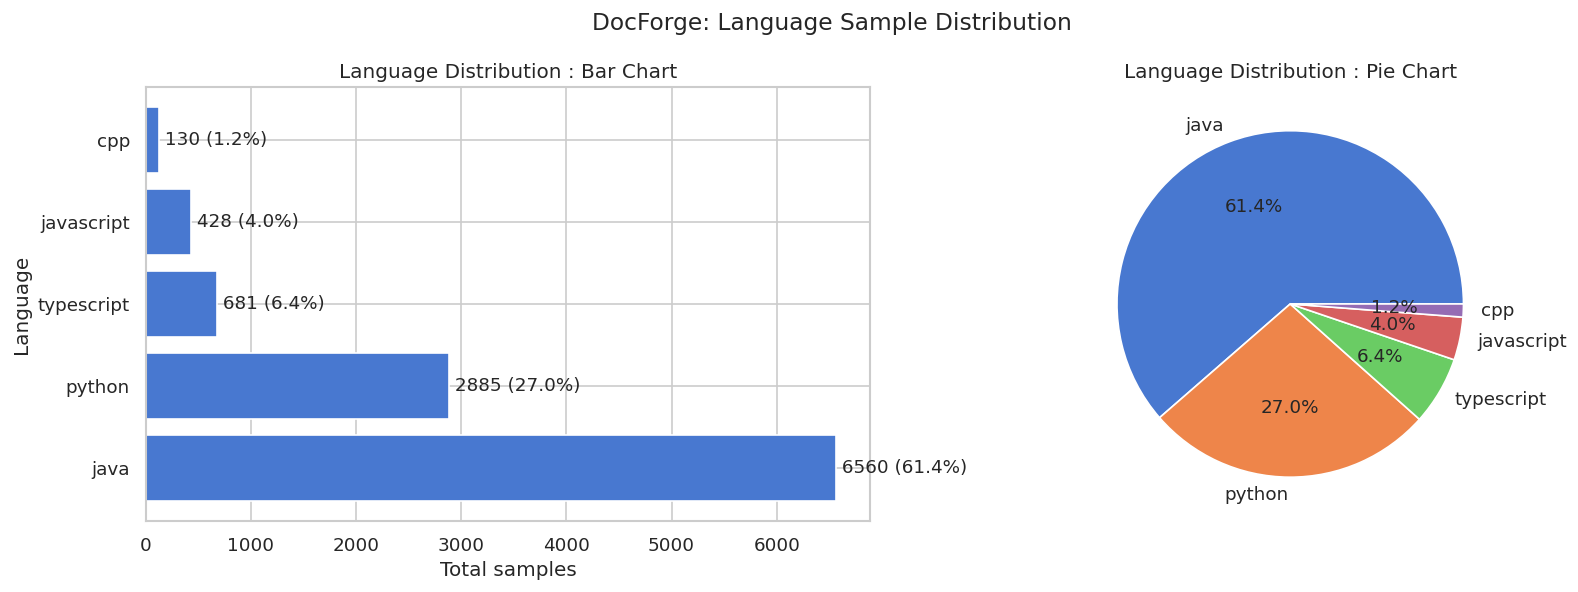

In [11]:
lang_counts = df["language"].value_counts()

total_samples = len(df)

for lang, count in lang_counts.items():
    percentage = (count / total_samples) * 100
    print(f"{lang}: {count} samples ({percentage:.2f}%)")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

percentages = (lang_counts / total_samples) * 100

ax[0].barh(lang_counts.index, lang_counts.values)

for i, (count, perc) in enumerate(zip(lang_counts.values, percentages)):
    ax[0].text(count, i, f" {count} ({perc:.1f}%)", va='center')

ax[0].set_xlabel("Total samples")
ax[0].set_ylabel("Language")
ax[0].set_title("Language Distribution : Bar Chart")

ax[1].pie(lang_counts.values,labels=lang_counts.index,autopct='%1.1f%%')
ax[1].set_title("Language Distribution : Pie Chart")

fig.suptitle("DocForge: Language Sample Distribution", fontsize=14)
plt.tight_layout()
plt.savefig("eda_language_distribution.png")

print("Observation: There is clearly uneven distribution of data ith diferent languages having varied lnumber of samples. Java has the most (61%) while cpp has the least(1.2%)")

---
## Section 5 — Quality Score Analysis

**Task:** Analyze the `quality_score` column — its distribution, key stats, and breakdown by language.

The quality score ranges from 0–10. All samples in this dataset should be ≥ 6.0.

**Hint:** Use `.describe()` for stats. Use `sns.boxplot` for the per-language breakdown.

Mean: 6.9247327
Median: 6.800000190734863
Standard Deviation: 0.6874250173568726
Minimum: 6.0
Maximum: 9.680000305175781
Q1: 6.400000095367432
Q3: 7.440000057220459


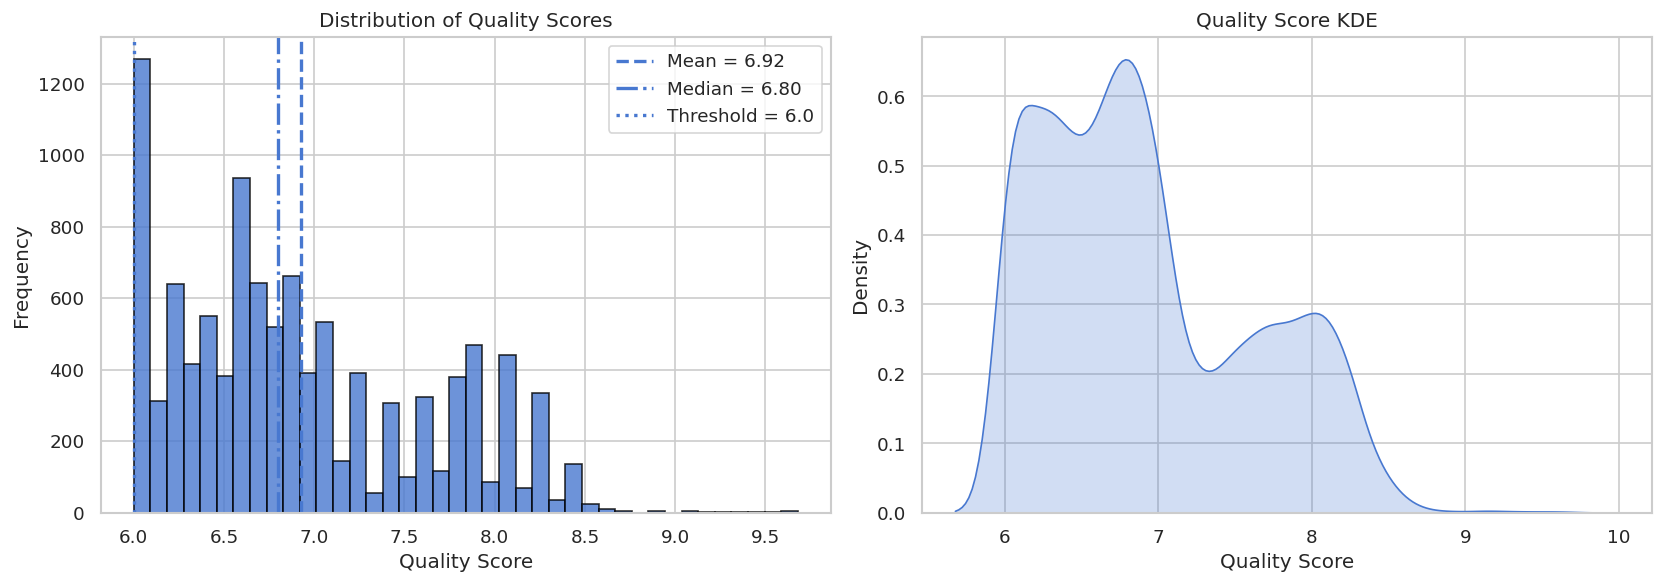

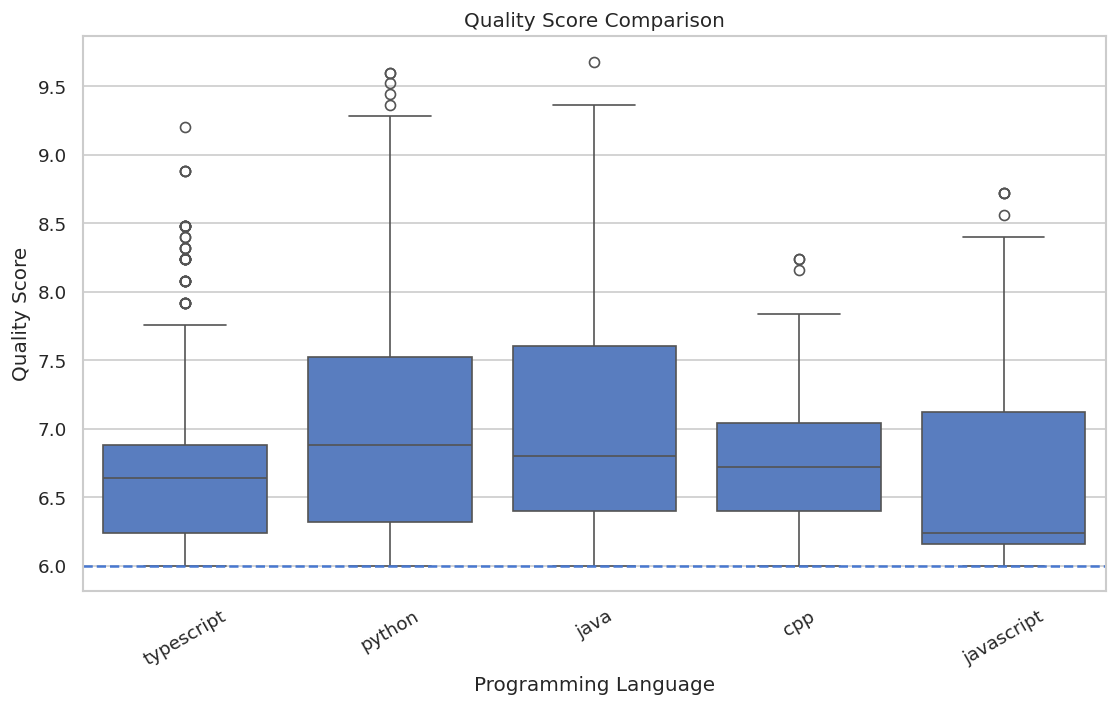


 Observation: The frequency of quality scores is higher in the threshold range but the actual value is much above ie in the 7.5 to 9.5 range


In [14]:
quality = df["quality_score"]

print("Mean:", quality.mean())
print("Median:", quality.median())
print("Standard Deviation:", quality.std())
print("Minimum:", quality.min())
print("Maximum:", quality.max())
print("Q1:", quality.quantile(0.25))
print("Q3:", quality.quantile(0.75))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax[0].hist(quality, bins=40, alpha=0.8, edgecolor="black")

ax[0].axvline(quality.mean(), linestyle="--", linewidth=2, label=f"Mean = {quality.mean():.2f}")

ax[0].axvline(quality.median(), linestyle="-.", linewidth=2, label=f"Median = {quality.median():.2f}")

ax[0].axvline(6.0, linestyle=":", linewidth=2, label="Threshold = 6.0")

ax[0].set_title("Distribution of Quality Scores")
ax[0].set_xlabel("Quality Score")
ax[0].set_ylabel("Frequency")
ax[0].legend()

sns.kdeplot(data=quality, fill=True, ax=ax[1])

ax[1].set_title("Quality Score KDE")
ax[1].set_xlabel("Quality Score")

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))

sns.boxplot(data=df, x="language", y="quality_score")

plt.axhline(y=6.0, linestyle="--", linewidth=1.5)

plt.title("Quality Score Comparison")
plt.xlabel("Programming Language")
plt.ylabel("Quality Score")

plt.xticks(rotation=30)

plt.show()

print("\n Observation: The frequency of quality scores is higher in the threshold range but the actual value is much above ie in the 7.5 to 9.5 range")

---
## Section 6 — Code Length Analysis

**Task:** Measure how long the functions are — in characters and in lines.

**Hint:** Use `.str.len()` for character count. Use `.str.count('\\n') + 1` for line count.
Cap your histograms at the 99th percentile so outliers don't squash the chart.

       code_char_len  code_line_count
count   10684.000000     10684.000000
mean      771.504586        20.584051
std       825.278555        21.907444
min        20.000000         1.000000
25%       197.000000         5.000000
50%       445.000000        12.000000
75%      1069.000000        29.000000
max      4990.000000       164.000000


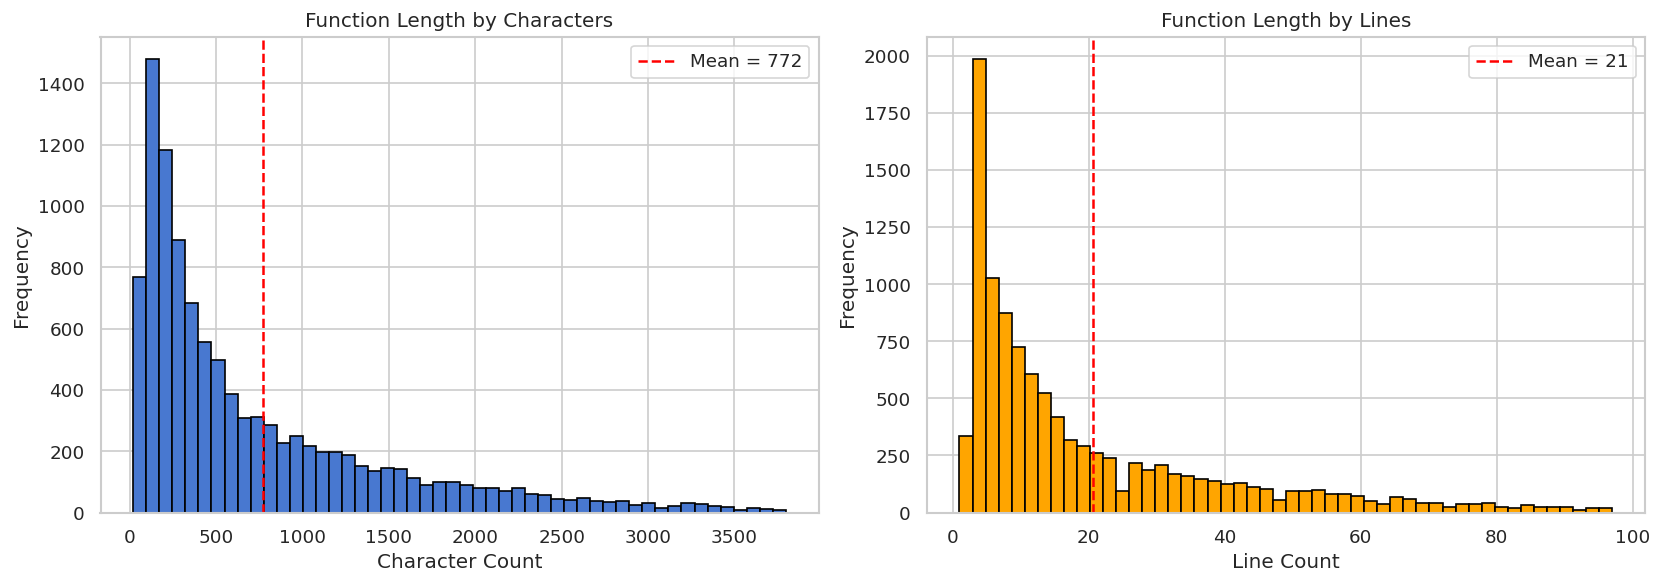

Observation: Both the length and the characters of the function are short with most of the the char being under 750 and lines under 20


In [17]:
df["code_char_len"] = df["function_code"].str.len()

df["code_line_count"] = df["function_code"].str.count("\n") + 1

print(df[["code_char_len", "code_line_count"]].describe())

char_cap = df["code_char_len"].quantile(0.99)

line_cap = df["code_line_count"].quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df.loc[df["code_char_len"] <= char_cap, "code_char_len"], bins=50, edgecolor="black")

ax[0].axvline(df["code_char_len"].mean(), color="red", linestyle="--", label=f"Mean = {df['code_char_len'].mean():.0f}")

ax[0].set_title("Function Length by Characters")
ax[0].set_xlabel("Character Count")
ax[0].set_ylabel("Frequency")
ax[0].legend()

ax[1].hist(df.loc[df["code_line_count"] <= line_cap, "code_line_count"], bins=50, color='orange', edgecolor="black")

ax[1].axvline(df["code_line_count"].mean(), color="red", linestyle="--", label=f"Mean = {df['code_line_count'].mean():.0f}")

ax[1].set_title("Function Length by Lines")
ax[1].set_xlabel("Line Count")
ax[1].set_ylabel("Frequency")
ax[1].legend()

plt.tight_layout()
plt.show()

median_chars = df["code_char_len"].median()
median_lines = df["code_line_count"].median()

print(f"Observation: Both the length and the characters of the function are short with most of the the char being under 750 and lines under 20")

---
## Section 7 — Docstring Length Analysis

**Task:** Measure how long the docstrings are, then compute the ratio of docstring length to code length.

A ratio > 1 means the docstring is longer than the code — which is actually fine for training.

       doc_char_len  doc_word_count
count  10684.000000    10684.000000
mean     410.318701       59.841164
std      364.138920       51.396198
min       50.000000        3.000000
25%      167.000000       26.000000
50%      285.000000       43.000000
75%      516.000000       76.000000
max     1998.000000      325.000000


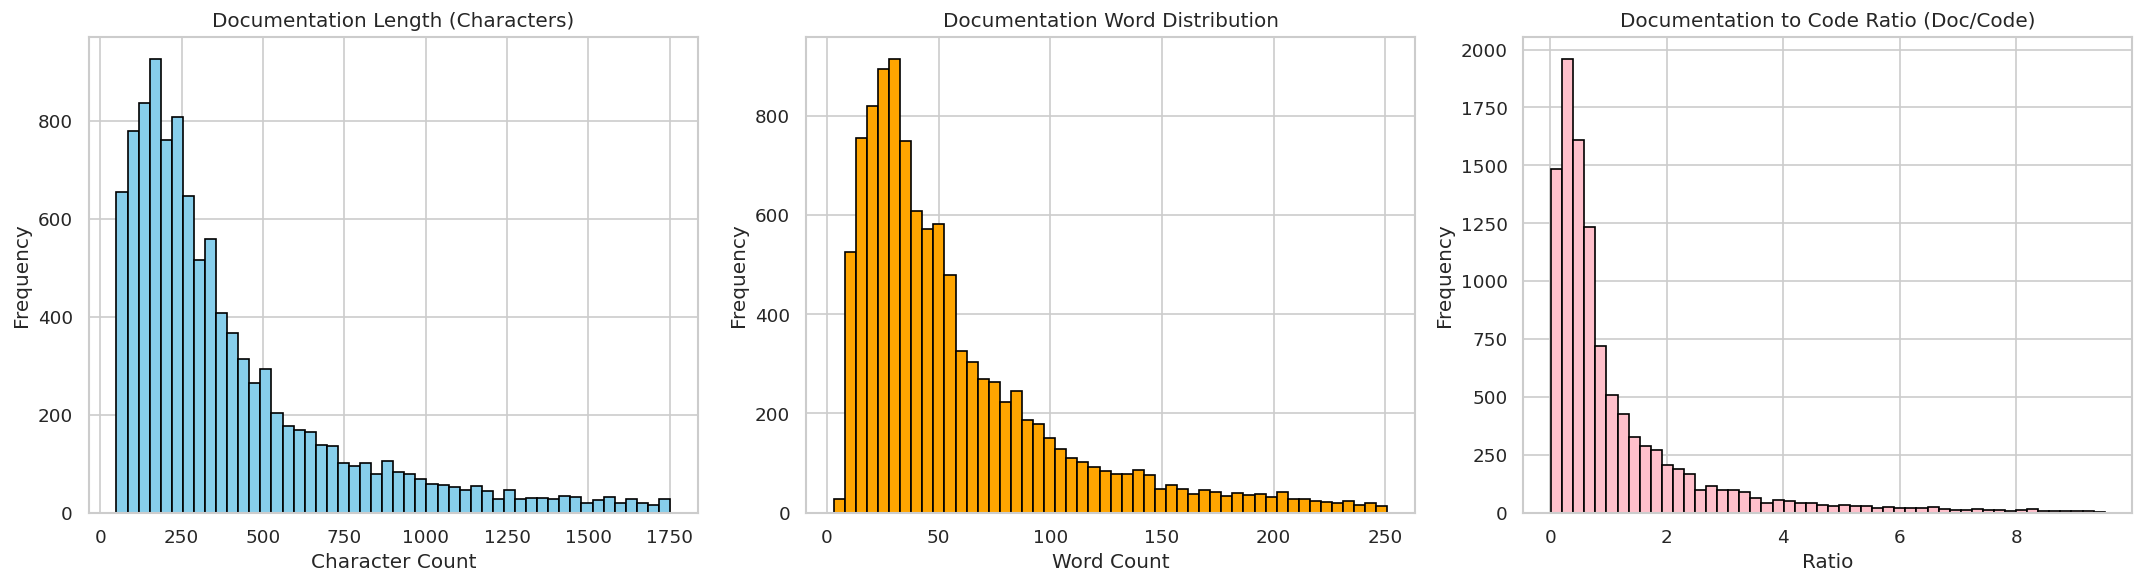

Observation: From the third histogram, we can clearly see that the doc/code ratio is less than 1 on average. This simply means that in most of the cases the function code is much longer than the docstring actually produced.


In [20]:
df["doc_char_len"] = df["documentation"].str.len()

df["doc_word_count"] = df["documentation"].str.split().str.len()

print(df[["doc_char_len", "doc_word_count"]].describe())

df["doc_to_code_ratio"] = df["doc_char_len"] / df["code_char_len"].replace(0, np.nan)

char_cap = df["doc_char_len"].quantile(0.99)
word_cap = df["doc_word_count"].quantile(0.99)
ratio_cap = df["doc_to_code_ratio"].quantile(0.99)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(df.loc[df["doc_char_len"] <= char_cap, "doc_char_len"], bins=50, color="skyblue", edgecolor="black")

ax[0].set_title("Documentation Length (Characters)")
ax[0].set_xlabel("Character Count")
ax[0].set_ylabel("Frequency")

ax[1].hist(df.loc[df["doc_word_count"] <= word_cap, "doc_word_count"], bins=50, color="orange", edgecolor="black")
ax[1].set_title("Documentation Word Distribution")
ax[1].set_xlabel("Word Count")
ax[1].set_ylabel("Frequency")

ax[2].hist(df.loc[df["doc_to_code_ratio"] <= ratio_cap, "doc_to_code_ratio"], bins=50, color="pink", edgecolor="black")
ax[2].set_title("Documentation to Code Ratio (Doc/Code)")
ax[2].set_xlabel("Ratio")
ax[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Observation: From the third histogram, we can clearly see that the doc/code ratio is less than 1 on average. This simply means that in most of the cases the function code is much longer than the docstring actually produced.")

---
## Section 8 — Token Count Estimation

**Task:** Estimate how many tokens each function and docstring will take up when fed to a model.

We can't load the tokenizer here due to a version conflict, so use this approximation:
> **tokens ≈ characters ÷ 4** (standard heuristic, accurate within ~10% for CodeT5)

Your goal is to find what `max_length` value covers at least 90% of samples.

       code_tokens  doc_tokens
count   2000.00000  2000.00000
mean     187.75550    99.34800
std      203.50293    91.09036
min        5.00000    12.00000
25%       47.00000    41.00000
50%      105.00000    68.00000
75%      267.25000   121.00000
max     1226.00000   491.00000


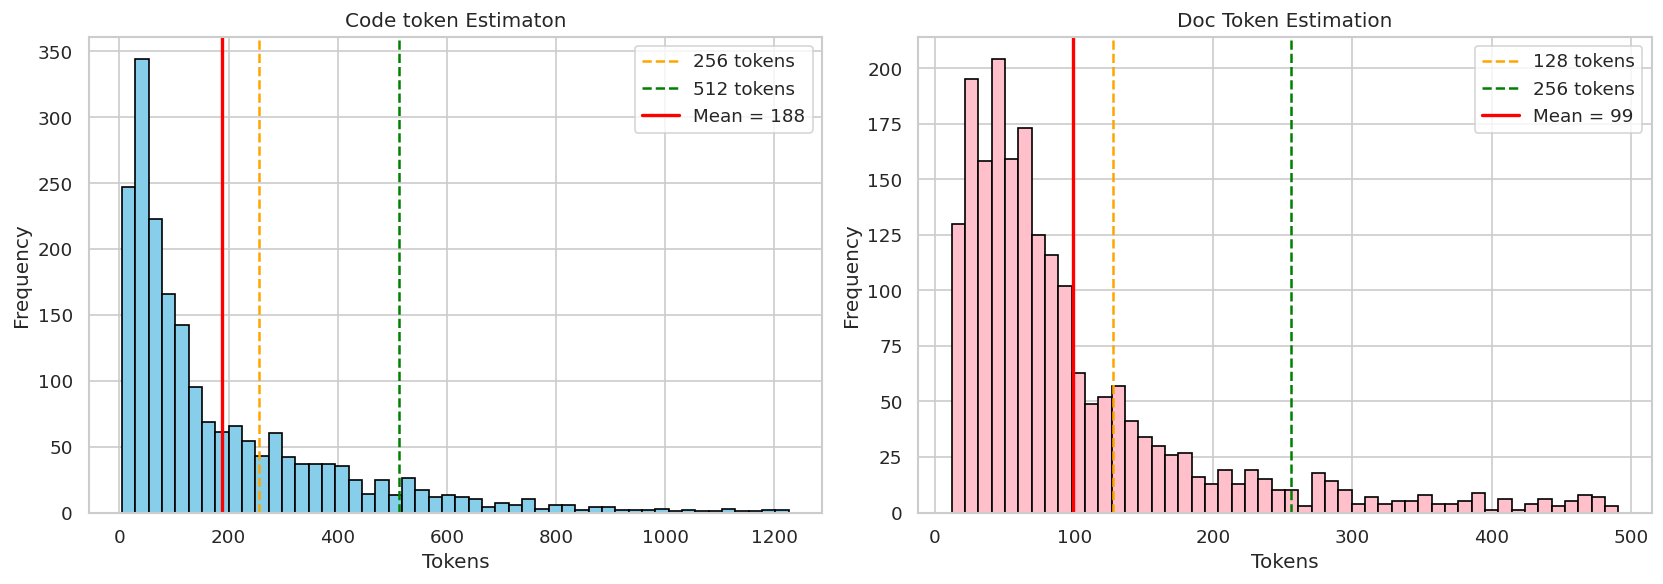

Code token coverage:
< 128 tokens: 56.1%
< 256 tokens: 73.9%
< 512 tokens: 91.6%
< 1024 tokens: 99.4%

Documentation token coverage:
< 64 tokens: 46.0%
< 128 tokens: 76.4%
< 256 tokens: 92.4%
< 512 tokens: 100.0%

Recommended max_input_length  = 512
Recommended max_target_length = 128


In [24]:
sample_df = df.sample(n=2000, random_state=42).copy()

sample_df["code_tokens"] = sample_df["code_char_len"] // 4

sample_df["doc_tokens"] = sample_df["doc_char_len"] // 4

print(sample_df[["code_tokens", "doc_tokens"]].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(sample_df["code_tokens"], bins=50, color="skyblue", edgecolor="black")
ax[0].axvline(256, color="orange", linestyle="--", label="256 tokens")
ax[0].axvline(512, color="green", linestyle="--", label="512 tokens")
ax[0].axvline(sample_df["code_tokens"].mean(), color="red", linestyle="-", linewidth=2, label=f"Mean = {sample_df['code_tokens'].mean():.0f}")

ax[0].set_title("Code token Estimaton")
ax[0].set_xlabel("Tokens")
ax[0].set_ylabel("Frequency")
ax[0].legend()

ax[1].hist(sample_df["doc_tokens"], bins=50, color="pink", edgecolor="black")
ax[1].axvline(128, color="orange", linestyle="--", label="128 tokens")
ax[1].axvline(256, color="green", linestyle="--", label="256 tokens")
ax[1].axvline(sample_df["doc_tokens"].mean(), color="red", linestyle="-", linewidth=2, label=f"Mean = {sample_df['doc_tokens'].mean():.0f}")

ax[1].set_title("Doc Token Estimation")
ax[1].set_xlabel("Tokens")
ax[1].set_ylabel("Frequency")
ax[1].legend()

plt.tight_layout()
plt.show()

print("Code token coverage:")

for limit in [128, 256, 512, 1024]:
    coverage = (sample_df["code_tokens"] < limit).mean() * 100
    print(f"< {limit} tokens: {coverage:.1f}%")

print("\nDocumentation token coverage:")

for limit in [64, 128, 256, 512]:
    coverage = (sample_df["doc_tokens"] < limit).mean() * 100
    print(f"< {limit} tokens: {coverage:.1f}%")

print("\nRecommended max_input_length  = 512")
print("Recommended max_target_length = 128")



---
## Section 9 — Cyclomatic Complexity

**Task:** Analyze the `complexity` column — this measures how many branches (if/else/for/while) a function has.

Low complexity = simple function. High complexity = hard to document automatically.
The dataset intentionally filters out very trivial AND very complex functions.

count    10684.000000
mean         3.373549
std          3.076487
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         51.000000
Name: complexity, dtype: float64
Median: 2.0


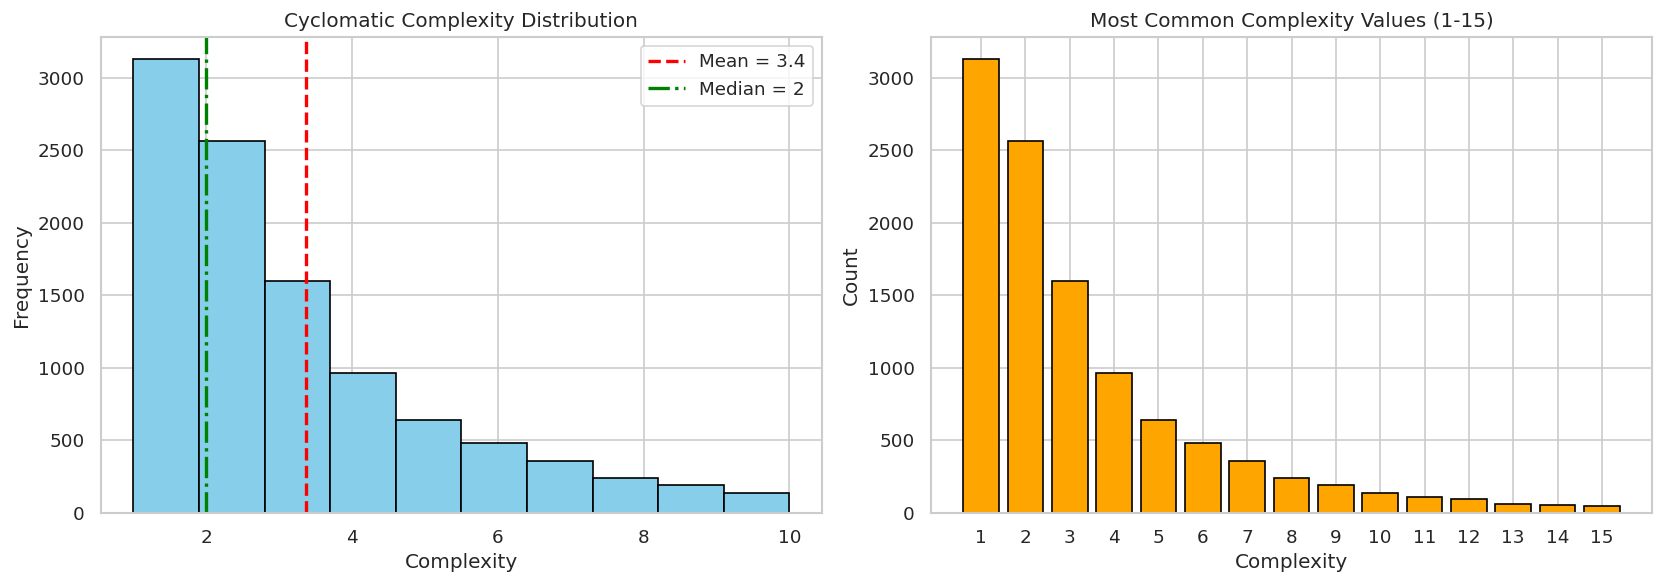

Observation:From the below 2 histograms we can say that the functions are small, simple with less branches as the complexity is relatively low (1-5) on average


In [27]:
complexity = df["complexity"]

print(complexity.describe())
print(f"Median: {complexity.median()}")

complexity_cap = complexity.quantile(0.95)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df.loc[df["complexity"] <= complexity_cap, "complexity"], bins=int(complexity_cap), color="skyblue", edgecolor="black")
ax[0].axvline(complexity.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {complexity.mean():.1f}")
ax[0].axvline(complexity.median(), color="green", linestyle="-.", linewidth=2, label=f"Median = {complexity.median():.0f}")

ax[0].set_title("Cyclomatic Complexity Distribution")
ax[0].set_xlabel("Complexity")
ax[0].set_ylabel("Frequency")
ax[0].legend()

top_values = complexity.value_counts().head(15).sort_index()

ax[1].bar(top_values.index.astype(str), top_values.values, color="orange", edgecolor="black")

ax[1].set_title("Most Common Complexity Values (1-15)")
ax[1].set_xlabel("Complexity")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Observation:From the below 2 histograms we can say that the functions are small, simple with less branches as the complexity is relatively low (1-5) on average")


---
## Section 10 — Per-Language Summary

**Task:** Build a summary table that shows, for each language:
- number of samples
- average code length (chars)
- average code length (lines)
- average docstring length (chars)
- average word count
- average quality score
- average complexity

Then visualize it as a heatmap.

            sample_count  avg_code_chars  avg_code_lines  avg_doc_chars  \
language                                                                  
cpp                  130          594.32           17.17         141.98   
java                6560          446.38           11.05         347.91   
javascript           428          505.48           16.53         338.39   
python              2885         1530.99           43.25         607.84   
typescript           681          886.93           19.64         271.15   

            avg_doc_words  avg_quality  avg_complexity  
language                                                
cpp                 22.65         6.72            3.76  
java                50.96         6.96            2.70  
javascript          50.55         6.62            4.04  
python              87.34         6.96            4.50  
typescript          41.84         6.64            4.56  


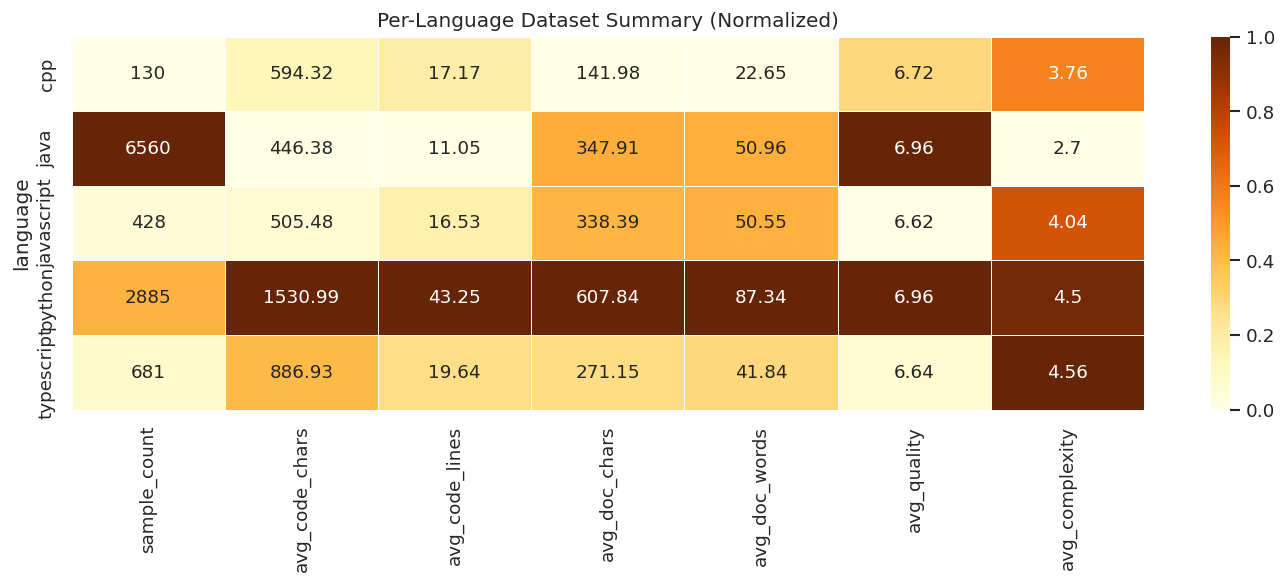

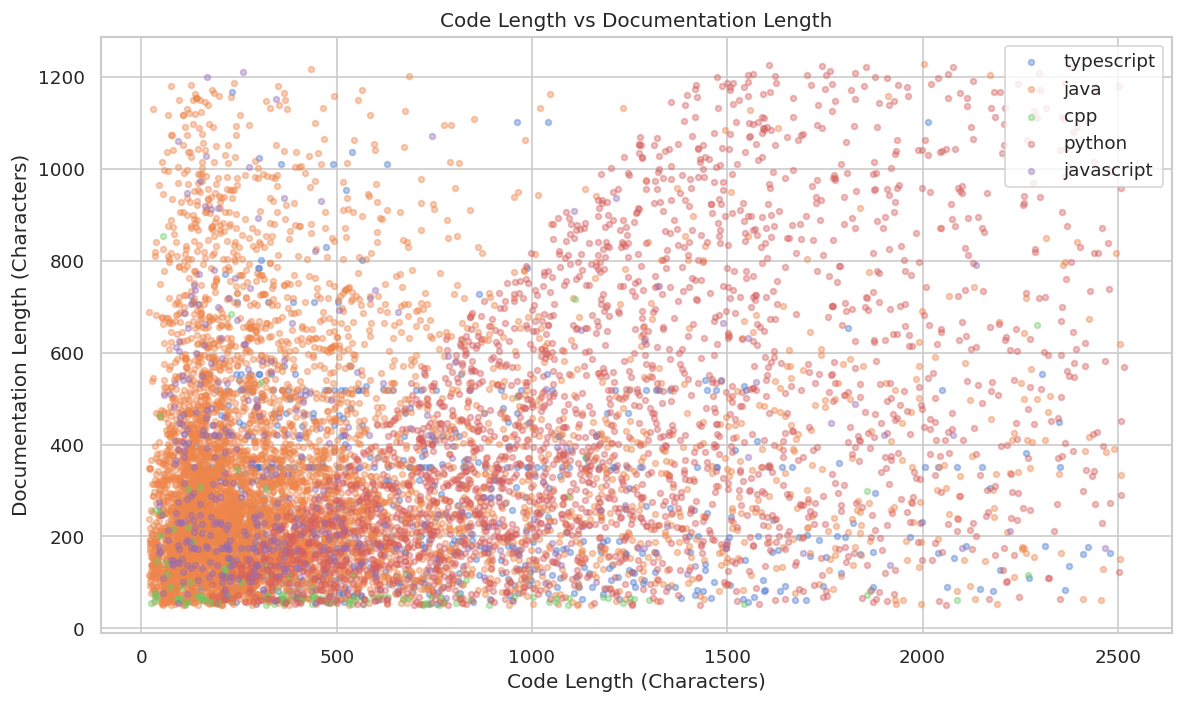

In [29]:
language_summary = df.groupby("language").agg(sample_count=("function_code", "count"), avg_code_chars=("code_char_len", "mean"), avg_code_lines=("code_line_count", "mean"), avg_doc_chars=("doc_char_len", "mean"), avg_doc_words=("doc_word_count", "mean"), avg_quality=("quality_score", "mean"), avg_complexity=("complexity", "mean")).round(2)

print(language_summary)

scaled_summary = (language_summary - language_summary.min()) / (language_summary.max() - language_summary.min())

plt.figure(figsize=(12, 5))
sns.heatmap(scaled_summary, annot=language_summary.values, fmt="g", cmap="YlOrBr", linewidths=0.5)
plt.title("Per-Language Dataset Summary (Normalized)")
plt.tight_layout()
plt.show()

code_limit = df["code_char_len"].quantile(0.95)
doc_limit = df["doc_char_len"].quantile(0.95)

filtered_df = df[(df["code_char_len"] <= code_limit) & (df["doc_char_len"] <= doc_limit)]

plt.figure(figsize=(10, 6))

for lang in filtered_df["language"].unique():
    temp = filtered_df[filtered_df["language"] == lang]

    plt.scatter(temp["code_char_len"], temp["doc_char_len"], alpha=0.4, s=12, label=lang)

plt.xlabel("Code Length (Characters)")
plt.ylabel("Documentation Length (Characters)")
plt.title("Code Length vs Documentation Length")
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 11 — Sample Inspection

**Task:** Look at actual examples from the dataset. Reading real samples is the best way to understand what the model will need to learn.

Print at least:
- 1 Python sample
- 1 Java sample
- The top 3 highest quality samples (any language)

In [30]:
def print_sample(row):
    print("=" * 70)
    print(f"Language: {row['language']}")
    print(f"Quality Score: {row['quality_score']}")
    print("-" * 70)
    print("Function Code:\n")
    print(str(row["function_code"])[:500])
    print("\n" + "-" * 70)
    print("Documentation:\n")
    print(str(row["documentation"])[:400])
    print("\n" + "=" * 70)

python_sample = df[df["language"] == "python"].iloc[0]

print("\nPython Example\n")

print_sample(python_sample)
java_sample = df[df["language"] == "java"].iloc[0]
print("\nJava Example\n")

print_sample(java_sample)
print("\nTop 3 Highest Quality Samples\n")
top_samples = df.nlargest(3, "quality_score")

for _, row in top_samples.iterrows():
    print_sample(row)


Python Example

Language: python
Quality Score: 6.960000038146973
----------------------------------------------------------------------
Function Code:

def convert(self, values: np.ndarray, nan_rep, encoding: str, errors: str):
        """
        Convert the data from this selection to the appropriate pandas type.

        Parameters
        ----------
        values : np.ndarray
        nan_rep :
        encoding : str
        errors : str

        Returns
        -------
        index : listlike to become an Index
        data : ndarraylike to become a column
        """
        assert isinstance(values, np.ndarray), type(values)

        # 

----------------------------------------------------------------------
Documentation:

Convert the data from this selection to the appropriate pandas type.

Parameters
----------
values : np.ndarray
nan_rep :
encoding : str
errors : str

Returns
-------
index : listlike to become an Index
data : ndarraylike to become a column


Java Example



---
## Section 12 — Key Insights Summary

**Task:** Fill in the summary below based on what you found in the analysis above.
This is the most important cell — it forces you to actually interpret the numbers.

Replace every `???` with the real value from your EDA.

In [31]:
dominant_lang = df["language"].value_counts().idxmax()

dominant_pct = (df["language"].value_counts(normalize=True).max()) * 100

code_512 = (sample_df["code_tokens"] < 512).mean() * 100

doc_256 = (sample_df["doc_tokens"] < 256).mean() * 100

print("=" * 60)
print("       DOCFORGE EDA — KEY INSIGHTS")
print("=" * 60)

print(f"""
Dataset
  Total samples         : {len(df)}
  Number of languages   : {df['language'].nunique()}
  Dominant language     : {dominant_lang} ({dominant_pct:.1f}%)

Quality Scores
  Mean                  : {df['quality_score'].mean():.2f}
  Std deviation         : {df['quality_score'].std():.2f}
  All samples above 6.0 : {"Yes" if (df['quality_score'] >= 6.0).all() else "No"}

Code Length
  Average chars         : {df['code_char_len'].mean():.1f}
  Average lines         : {df['code_line_count'].mean():.1f}

Docstring Length
  Average chars         : {df['doc_char_len'].mean():.1f}
  Average words         : {df['doc_word_count'].mean():.1f}

Complexity
  Mean cyclomatic CC    : {df['complexity'].mean():.2f}
  Median cyclomatic CC  : {df['complexity'].median():.2f}

Token Estimates (chars / 4)
  % code fits in 512    : {code_512:.1f}%
  % doc fits in 256     : {doc_256:.1f}%

Recommended Settings for Notebook 2
  max_input_length      : 512
  max_target_length     : 128
""")

print("=" * 60)

       DOCFORGE EDA — KEY INSIGHTS

Dataset
  Total samples         : 10684
  Number of languages   : 5
  Dominant language     : java (61.4%)

Quality Scores
  Mean                  : 6.92
  Std deviation         : 0.69
  All samples above 6.0 : Yes

Code Length
  Average chars         : 771.5
  Average lines         : 20.6

Docstring Length
  Average chars         : 410.3
  Average words         : 59.8

Complexity
  Mean cyclomatic CC    : 3.37
  Median cyclomatic CC  : 2.00

Token Estimates (chars / 4)
  % code fits in 512    : 91.6%
  % doc fits in 256     : 92.4%

Recommended Settings for Notebook 2
  max_input_length      : 512
  max_target_length     : 128



---
##  Done!

Before moving to preprocessing, make sure you can answer these questions:

1. What are the 5 programming languages in the dataset and their proportions?
2. Why does Java dominate — what does that tell us about documentation culture?
3. What is the quality score range and what does the minimum threshold of 6.0 mean?
4. What `max_input_length` and `max_target_length` will you use for CodeT5 and why?
5. What is cyclomatic complexity and why does the dataset filter out very high values?
6. What does a doc-to-code ratio > 1 mean — is it a problem?

Write your answers in the cell below as comments.

In [ ]:
# Q1: Languages and proportions
# Answer: 
# The 5 languages are:
# Java - 61.4 %
# Python - 27 %
# typescript - 6.4 %
# javascript - 4 %
# cpp - 1.2 % 

# Q2: Why does Java dominate?
# Answer: Java is a very efficient programming language with a structured flow. Also, Java has a very strong documentation culture - JavaDoc,  
# making it useful for code2doc tasks like this and creating samples for CodeT5.

# Q3: Quality score range and what 6.0 means
# Answer: Quality score represents how good the code2doc representation is. The quality score range in this dataset is between 6-10.
# 6 is the minimum threshold that we have defined. Any score below 6 would have more errors in it and hence be considered less reliable.

# Q4: max_input_length and max_target_length choice
# Answer: max_input_length is the maximum length of the function code that is possible. It cannot exceed this number. Here,  max_input_length =  512
# So, most coding samples can fit within this range. max_target_length choice = 128. We chose this value as in most of the cases (and in this dataset),
# the docstring is actually lesser than the actual code itself. Thus, we chose a smaller value to not waste training time and increase efficiency.

# Q5: What is cyclomatic complexity?
# Answer: This means how complex the code function is, i.e., how many branches (if/else/for/while) a function has. If this number is low, it is a
# simple function with relatively lower branches and vice versa. The complexity in this DocForge is low ie easier to summarise.

# Q6: doc-to-code ratio > 1
# Answer: This would mean that the docstring generated is actually longer than the code itself. This actually means that the code is 
# performing really well. Now, even smaller bits of code can create more in-depth analysis with a docstring. Thus, the higher the better.
